Image shape : (261, 352)
Pixel range : 0 – 254

Applying manual 3×3 median filter...
Done!
Manual vs OpenCV max difference: 109 (should be 0 or 1)

Before filtering → Salt: 378, Pepper: 335, Noise density: 0.78%
After  filtering → Salt: 1, Pepper: 1, Noise density: 0.00%
Noise removed    → 0.77% of pixels cleaned

Contrast Enhancement (Hist. Eq.)
  Filtered → mean=144.4, std=35.8
  Enhanced → mean=129.0, std=74.2


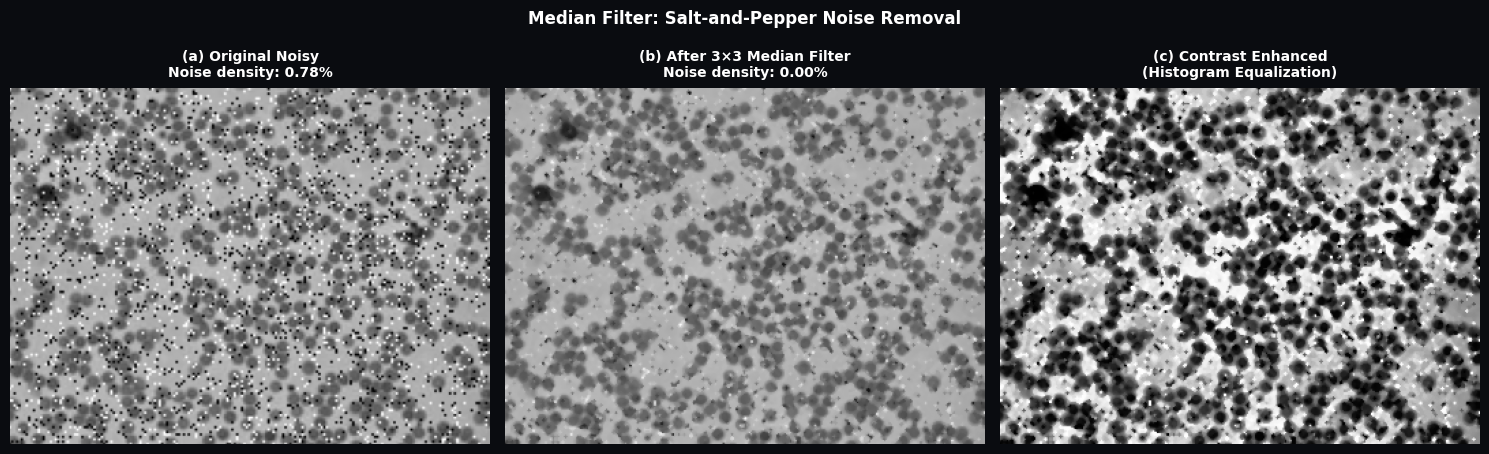

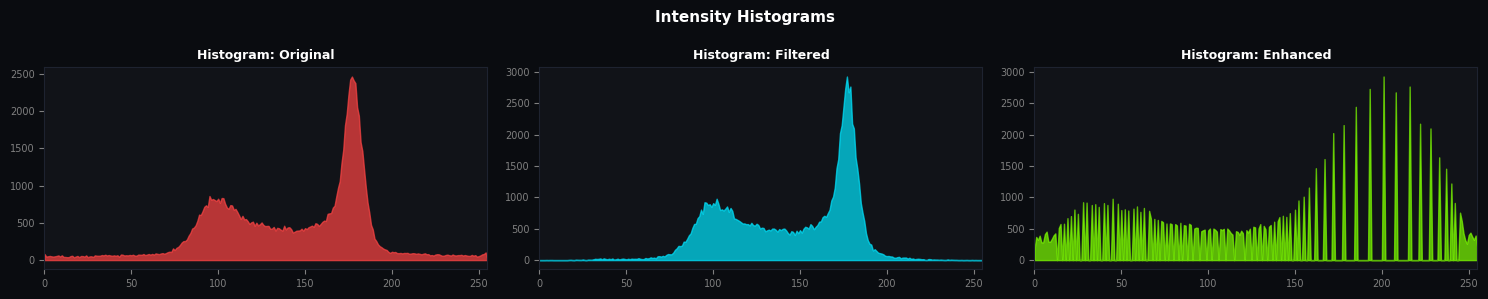

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


img = cv2.imread("/content/S&P.png", cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Could not load image!")

print(f"Image shape : {img.shape}")
print(f"Pixel range : {img.min()} – {img.max()}")

def median_filter_3x3(img):

    H, W = img.shape
    output = np.zeros_like(img)

    # Pad image by 1 pixel on all sides (reflect = mirror border)
    padded = np.pad(img, pad_width=1, mode='reflect')

    for r in range(H):
        for c in range(W):
            # Extract 3x3 neighbourhood from padded image
            patch = padded[r:r+3, c:c+3]       # shape (3,3)
            neighbours = patch.flatten()         # 9 values
            output[r, c] = np.median(neighbours) # sorted middle value

    return output


print("\nApplying manual 3×3 median filter...")
filtered_manual = median_filter_3x3(img)
print("Done!")

# ── Also apply OpenCV's built-in (fast, same result) ──
filtered_cv = cv2.medianBlur(img, ksize=3)

# Verify they match
diff = np.abs(filtered_manual.astype(int) - filtered_cv.astype(int))
print(f"Manual vs OpenCV max difference: {diff.max()} (should be 0 or 1)")


def count_salt_pepper(image, thresh=5):
    salt    = np.sum(image >= 255 - thresh)
    pepper  = np.sum(image <= thresh)
    total   = image.size
    density = (salt + pepper) / total * 100
    return salt, pepper, density

s1, p1, d1 = count_salt_pepper(img)
s2, p2, d2 = count_salt_pepper(filtered_cv)

print(f"\nBefore filtering → Salt: {s1}, Pepper: {p1}, Noise density: {d1:.2f}%")
print(f"After  filtering → Salt: {s2}, Pepper: {p2}, Noise density: {d2:.2f}%")
print(f"Noise removed    → {d1 - d2:.2f}% of pixels cleaned")

#Hist eq
enhanced = cv2.equalizeHist(filtered_cv)

print(f"\nContrast Enhancement (Hist. Eq.)")
print(f"  Filtered → mean={filtered_cv.mean():.1f}, std={filtered_cv.std():.1f}")
print(f"  Enhanced → mean={enhanced.mean():.1f}, std={enhanced.std():.1f}")

#########################
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#0a0c10')

images = [img,         filtered_cv,           enhanced]
titles = [
    f"(a) Original Noisy\nNoise density: {d1:.2f}%",
    f"(b) After 3×3 Median Filter\nNoise density: {d2:.2f}%",
    f"(c) Contrast Enhanced\n(Histogram Equalization)"
]
border_colors = ['#ff4444', '#00e5ff', '#7cfc00']

for ax, image, title, bcolor in zip(axes, images, titles, border_colors):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, color='white', fontsize=10,
                 fontweight='bold', pad=8)
    ax.axis('off')
    ax.set_facecolor('#111318')
    for spine in ax.spines.values():
        spine.set_edgecolor(bcolor)
        spine.set_linewidth(2)

# ── Histogram comparison below ──
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 3))
fig2.patch.set_facecolor('#0a0c10')

hist_data   = [img, filtered_cv, enhanced]
hist_colors = ['#ff4444', '#00e5ff', '#7cfc00']
hist_titles = ["Histogram: Original", "Histogram: Filtered", "Histogram: Enhanced"]

for ax, image, color, title in zip(axes2, hist_data, hist_colors, hist_titles):
    hist_vals, _ = np.histogram(image.flatten(), bins=256, range=(0, 256))
    ax.fill_between(range(256), hist_vals, color=color, alpha=0.7)
    ax.set_title(title, color='white', fontsize=9, fontweight='bold')
    ax.set_facecolor('#111318')
    ax.tick_params(colors='gray', labelsize=7)
    ax.set_xlim(0, 255)
    for s in ax.spines.values(): s.set_color('#1e2330')

fig.suptitle("Median Filter: Salt-and-Pepper Noise Removal",
             color='white', fontsize=12, fontweight='bold')
fig2.suptitle("Intensity Histograms",
              color='white', fontsize=11, fontweight='bold')

plt.figure(fig.number)
plt.tight_layout()
plt.savefig("median_filter_result.png", dpi=150,
            bbox_inches='tight', facecolor='#0a0c10')

plt.figure(fig2.number)
plt.tight_layout()

plt.show()
#This was median filter applied to salt and pepper noise

Gaussian noise has zero mean: E[noise] = 0
Mean filter computes: output = (1/9) Σ (signal + noise)
= signal + (1/9) Σ noise → signal + 0 = clean signal

The more neighbours you average, the more the noise cancels out and this only works because Gaussian noise is symmetric around zero.

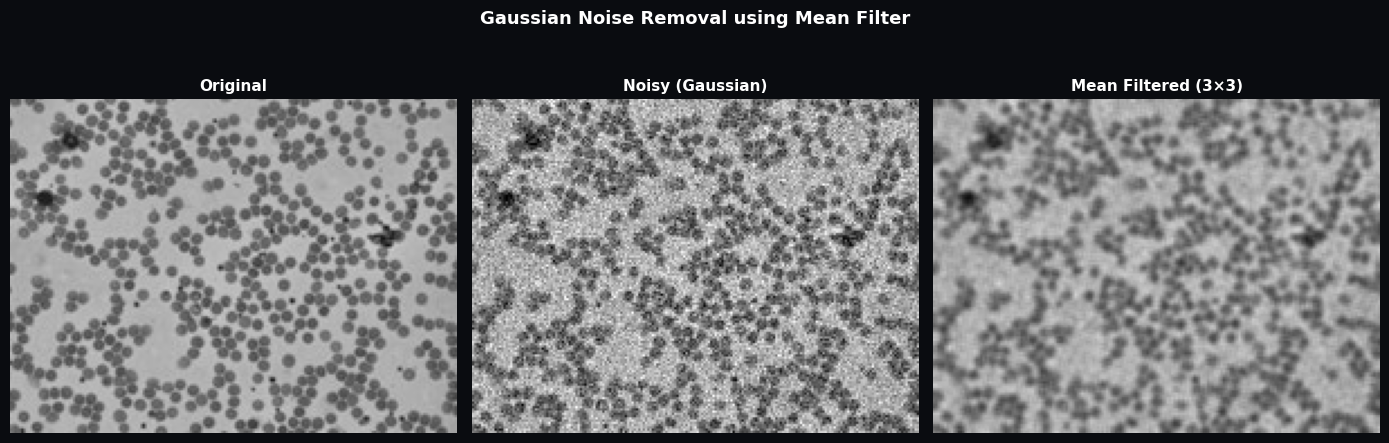

In [3]:
img = cv2.imread("/content/Microscopic image.jpg", cv2.IMREAD_GRAYSCALE)

# Adding the chosen gaussian noise
noise = np.random.normal(0, 25, img.shape)
noisy = np.clip(img.astype(np.float64) + noise, 0, 255).astype(np.uint8)

# Mean filter
kernel   = np.ones((3, 3), dtype=np.float32) / 9.0
filtered = cv2.filter2D(noisy, -1, kernel)

#Plotting
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor('#0a0c10')

images = [img,         noisy,              filtered]
titles = ["Original",  "Noisy (Gaussian)", "Mean Filtered (3×3)"]

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, color='white', fontsize=11, fontweight='bold')
    ax.axis('off')
    ax.set_facecolor('#111318')

plt.suptitle("Gaussian Noise Removal using Mean Filter",
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#This was gaussian noise removed using mean filter

Gaussian filter smooths the granular texture that speckle creates by averaging with weighted neighbours (center pixel weighted more than edges)
It's the standard filter used in ultrasound and MRI speckle reduction

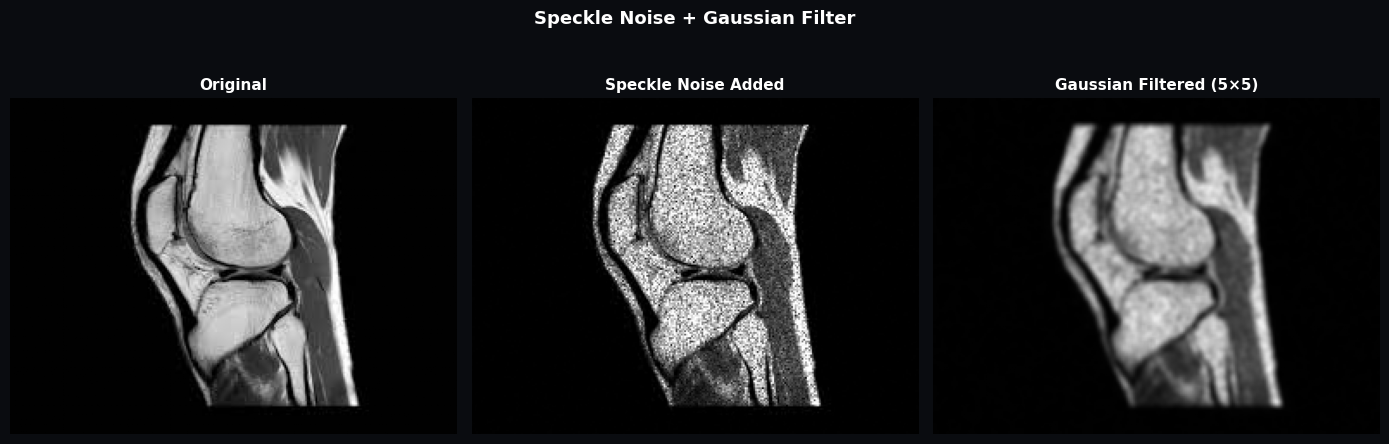

In [4]:
img = cv2.imread("/content/images (1).jfif", cv2.IMREAD_GRAYSCALE)

#  Add Speckle Noise (multiplicative)
# Formula: noisy = img + img * noise
noise = np.random.normal(0, 0.3, img.shape)
noisy = np.clip(img.astype(np.float64) + img.astype(np.float64) * noise, 0, 255).astype(np.uint8)

# Gaussian filter best for speckle noise
filtered = cv2.GaussianBlur(noisy, (5, 5), sigmaX=1.5)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor('#0a0c10')

images = [img,        noisy,                filtered]
titles = ["Original", "Speckle Noise Added", "Gaussian Filtered (5×5)"]

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, color='white', fontsize=11, fontweight='bold')
    ax.axis('off')
    ax.set_facecolor('#111318')

plt.suptitle("Speckle Noise + Gaussian Filter",
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("speckle_filter_result.png", dpi=150,
            bbox_inches='tight', facecolor='#0a0c10')
plt.show()

#Q4

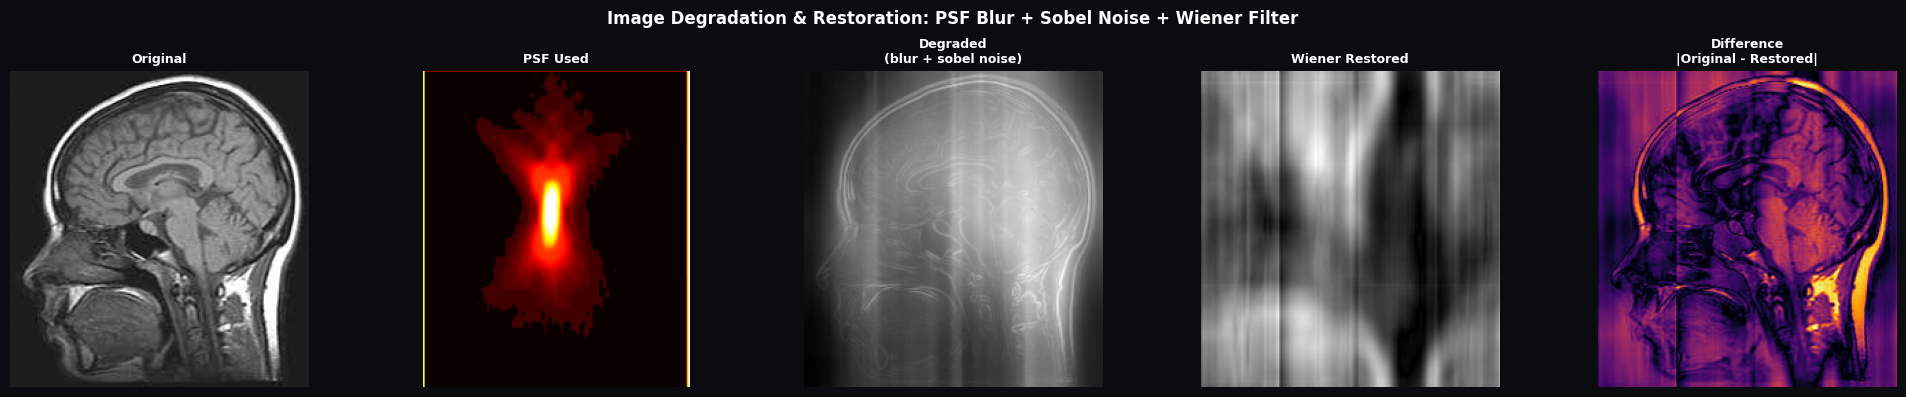

In [7]:
from scipy.signal import convolve2d


img = cv2.imread("/content/download (2).jfif", cv2.IMREAD_GRAYSCALE)
img = img.astype(np.float64)

#PSF/Given image
psf_img = cv2.imread("/content/PSF.png", cv2.IMREAD_GRAYSCALE)
psf = psf_img.astype(np.float64)
psf = psf / psf.sum()

blurred = convolve2d(img, psf, mode='same', boundary='symm')


# Add Sobel-based noise
# Sobel detects edges → adding it simulates
# edge-correlated sensor noise
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel   = np.sqrt(sobel_x**2 + sobel_y**2)
sobel   = sobel / sobel.max()          # normalize to 0-1

degraded = np.clip(blurred + 0.1 * sobel * 255, 0, 255)

#Wiener filter
# Works in frequency domain:
#   H  = FFT of PSF
#   G  = FFT of degraded image
#   Wiener = G × H* / (|H|² + K)
#   K = noise-to-signal ratio (small constant)
def wiener_filter(degraded, psf, K=0.01):
    # Pad PSF to image size
    psf_padded = np.zeros_like(degraded)
    ph, pw = psf.shape
    psf_padded[:ph, :pw] = psf

    # FFT
    G = np.fft.fft2(degraded)
    H = np.fft.fft2(psf_padded)

    # Wiener formula
    H_conj   = np.conj(H)
    restored = (H_conj / (np.abs(H)**2 + K)) * G

    # Inverse FFT
    result = np.abs(np.fft.ifft2(restored))
    return np.clip(result, 0, 255).astype(np.uint8)

restored = wiener_filter(degraded, psf, K=0.01)

#Plotting
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.patch.set_facecolor('#0a0c10')

images = [img,        psf,        degraded,              restored]
titles = ["Original", "PSF Used", "Degraded\n(blur + sobel noise)", "Wiener Restored"]
cmaps  = ['gray',     'hot',      'gray',                'gray']

for ax, image, title, cmap in zip(axes[:4], images, titles, cmaps):
    ax.imshow(image, cmap=cmap)
    ax.set_title(title, color='white', fontsize=9, fontweight='bold')
    ax.axis('off')
    ax.set_facecolor('#111318')

# Difference map: how much was recovered
diff = np.abs(img - restored.astype(np.float64))
axes[4].imshow(diff, cmap='inferno')
axes[4].set_title("Difference\n|Original - Restored|", color='white', fontsize=9, fontweight='bold')
axes[4].axis('off')
axes[4].set_facecolor('#111318')

plt.suptitle("Image Degradation & Restoration: PSF Blur + Sobel Noise + Wiener Filter",
             color='white', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#Q5

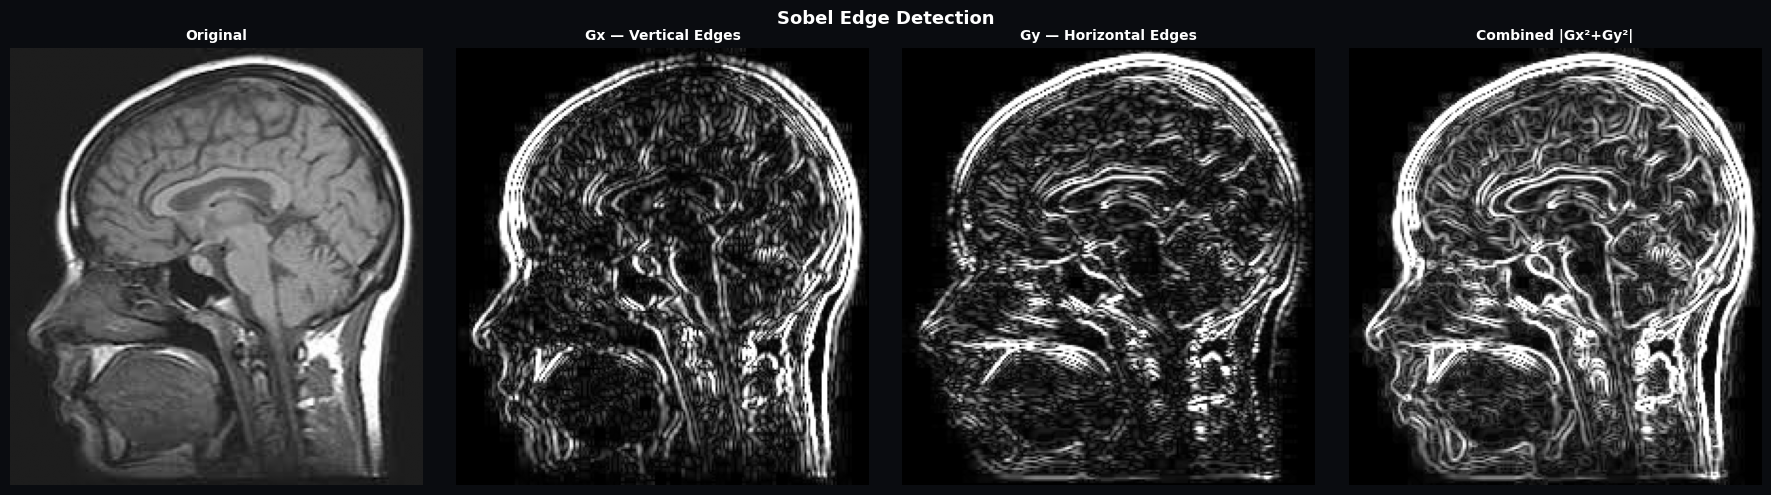

In [8]:
# Load image
img = cv2.imread("/content/download (2).jfif", cv2.IMREAD_GRAYSCALE)

# Hardcoded sobel kernels
Gx = np.array([[-1, 0, 1],
               [-2, 0, 2],
               [-1, 0, 1]], dtype=np.float64)

Gy = np.array([[-1, -2, -1],
               [ 0,  0,  0],
               [ 1,  2,  1]], dtype=np.float64)


edges_x  = cv2.filter2D(img, cv2.CV_64F, Gx)   # vertical edges
edges_y  = cv2.filter2D(img, cv2.CV_64F, Gy)   # horizontal edges
magnitude = np.sqrt(edges_x**2 + edges_y**2)   # combined

# Normalize to 0-255 for display
edges_x   = np.clip(np.abs(edges_x),  0, 255).astype(np.uint8)
edges_y   = np.clip(np.abs(edges_y),  0, 255).astype(np.uint8)
magnitude = np.clip(magnitude,         0, 255).astype(np.uint8)

#Plotting
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.patch.set_facecolor('#0a0c10')

images = [img,        edges_x,                  edges_y,                    magnitude]
titles = ["Original", "Gx — Vertical Edges",    "Gy — Horizontal Edges",    "Combined |Gx²+Gy²|"]

for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, color='white', fontsize=10, fontweight='bold')
    ax.axis('off')
    ax.set_facecolor('#111318')

plt.suptitle("Sobel Edge Detection", color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("edge_detection.png", dpi=150, bbox_inches='tight', facecolor='#0a0c10')
plt.show()

Gx — detects vertical edges (responds to left-right intensity changes)
Gy — detects horizontal edges (responds to top-bottom intensity changes)
Combined — √(Gx² + Gy²) gives full edge map in all directions